In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [4]:
file_names = [
    "M13_0001.fits",
    "M13_0002.fits",
    "M13_0003.fits",
    "M13_0004.fits",
    "M13_0005.fits"]


images = []

for file in file_names:
    with fits.open(file) as hdul:
        data = hdul[0].data
        images.append(data)

In [5]:
images = []

for file in file_names:
    with fits.open(file) as hdul:
        data = hdul[0].data
        images.append(data)

print(len(images))

5


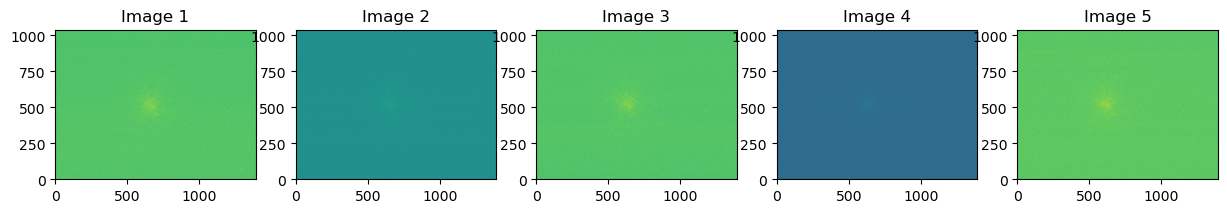

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    axes[i].imshow(images[i], origin="lower")
    axes[i].set_title(f"Image {i+1}")

plt.show()

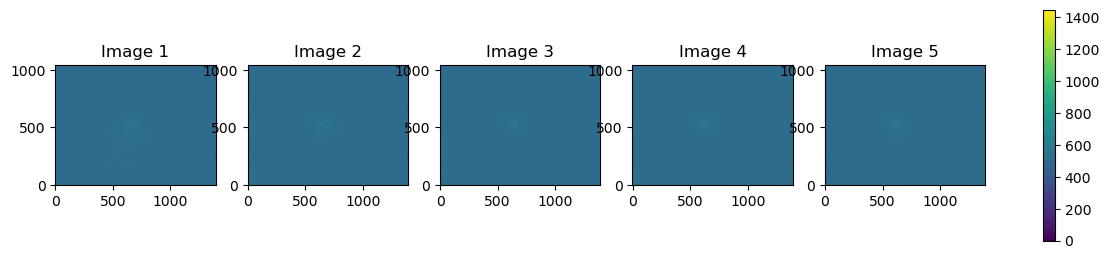

In [7]:
vmin = min(img.min() for img in images)
vmax = max(img.max() for img in images)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    im = axes[i].imshow(images[i], origin="lower", vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Image {i+1}")

fig.colorbar(im, ax=axes)
plt.show()

The differences I notice is that using the same color scale makes the images easier to compare directly. The brightness and contrast are consistent across all images, revealing differences in intensity more clearly. The stars and central cluster become more distinguishable compared to the previous plots.

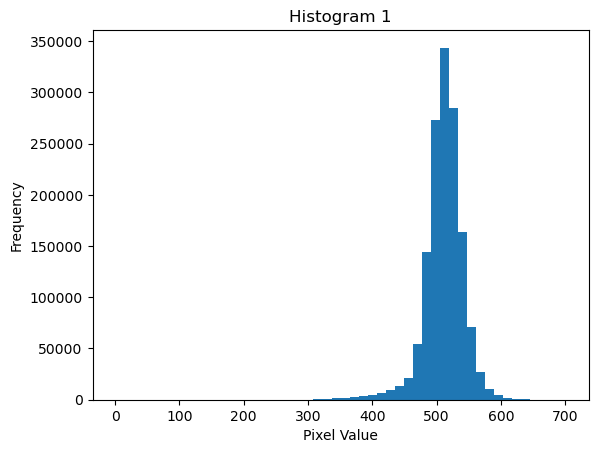

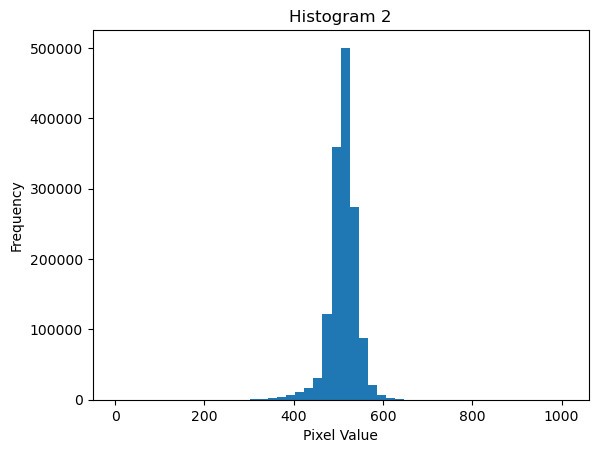

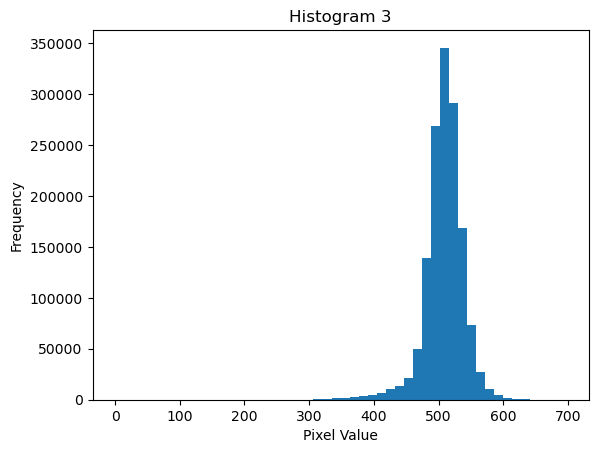

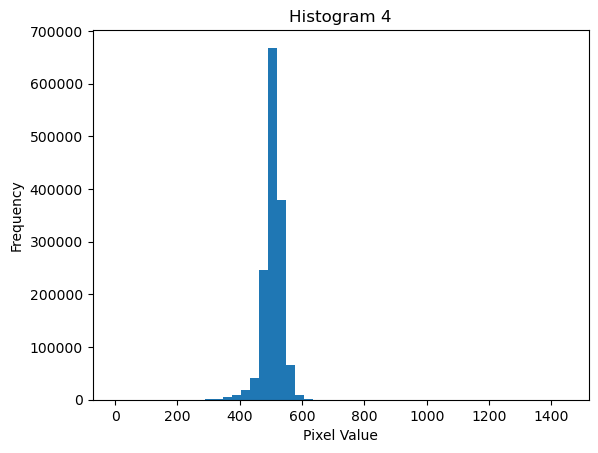

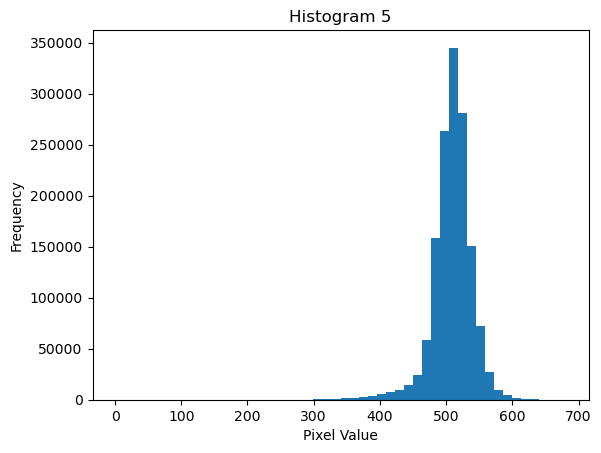

In [9]:
for i, img in enumerate(images):
    plt.figure()
    plt.hist(img.ravel(), bins=50)
    plt.title(f"Histogram {i+1}")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.show()

x-axis = pixel intensity

y-axis = frequency


bins=50 divides the data into 50 intervals

Most values are concentrated at low pixel intensities

The data is tightly clustered with a few high-value outliers

In [10]:
for img in images:
    print("Mean:", np.mean(img), "Median:", np.median(img))

Mean: 510.4706668600796 Median: 512.0
Mean: 509.7460150033157 Median: 511.0
Mean: 508.0498729000884 Median: 510.0
Mean: 507.90583554376656 Median: 509.0
Mean: 508.7919920148099 Median: 510.0


In [11]:
combined = np.median(images, axis=0)

In [12]:
print(np.median(combined))

510.0


510.0 is the new median pixel intensity

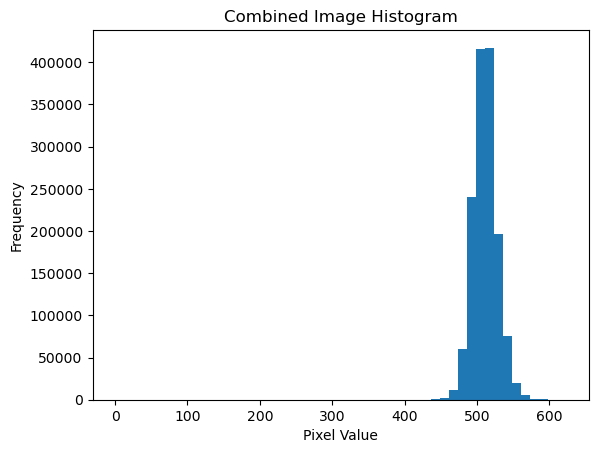

In [13]:
plt.hist(combined.ravel(), bins=50)
plt.title("Combined Image Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

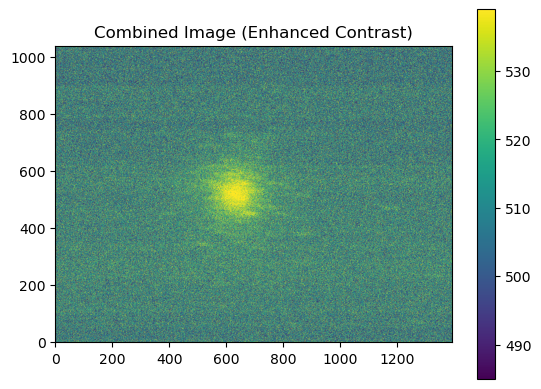

In [14]:
vmin = np.percentile(combined, 5)
vmax = np.percentile(combined, 95)

plt.imshow(combined, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title("Combined Image (Enhanced Contrast)")
plt.show()

The combined image has significantly reduced noise compared to individual images. The central star cluster appears clearer and more defined, and faint details are more visible. Overall contrast and image quality are improved due to stacking and normalization.

In [15]:
fits.writeto("combined.fits", combined, overwrite=True)

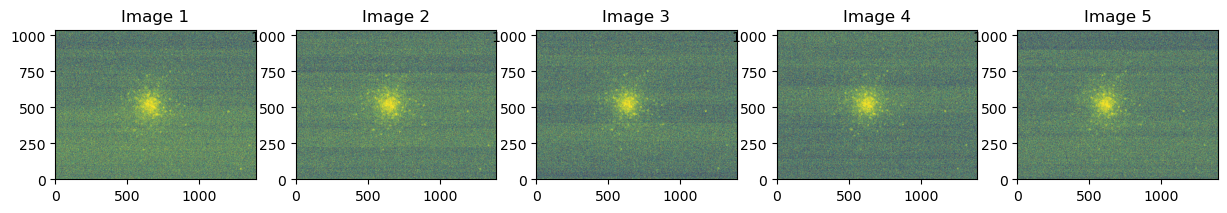

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    axes[i].imshow(images[i], origin="lower", vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Image {i+1}")

plt.show()

Applying the same normalization to the original images improves visibility, but they still appear noisier compared to the combined image.